# =============================================================================
# CELL 1: Imports & Setup
# =============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
# Paths for the tabular models and data
DATA_DIR = "/kaggle/input/datasets/jaykalbi/credit-risk-output/data/processed"
MODELS_DIR = "/kaggle/input/datasets/jaykalbi/credit-risk-output/models"
# TODO: Double check this path on the right hand panel!
RATIONALES_PATH = "/kaggle/input/your-notebook-5-name/llm_rationales.json"

# =============================================================================
# CELL 2: Load Data & Models
# =============================================================================

In [3]:
print("Loading Data and Models for Explainability...")
X_test = np.load(f"{DATA_DIR}/X_test.npy")
y_test = np.load(f"{DATA_DIR}/y_test.npy")
test_df = pd.read_csv(f"{DATA_DIR}/test_df.csv")
with open(f"{DATA_DIR}/feature_names.json", 'r') as f:
    feature_names = json.load(f)
lgb_model = joblib.load(f"{MODELS_DIR}/lightgbm.joblib")
try:
    with open(RATIONALES_PATH, 'r') as f:
        llm_rationales = json.load(f)
    print("Successfully loaded LLM rationales!")
except Exception as e:
    print(f"Could not load rationales (check RATIONALES_PATH): {e}")
    llm_rationales = []

Loading Data and Models for Explainability...
Could not load rationales (check RATIONALES_PATH): [Errno 2] No such file or directory: '/kaggle/input/your-notebook-5-name/llm_rationales.json'


# =============================================================================
# CELL 3: SHAP Analysis
# =============================================================================

Computing SHAP values (This takes ~30 seconds)...
Generating SHAP Summary Plot...


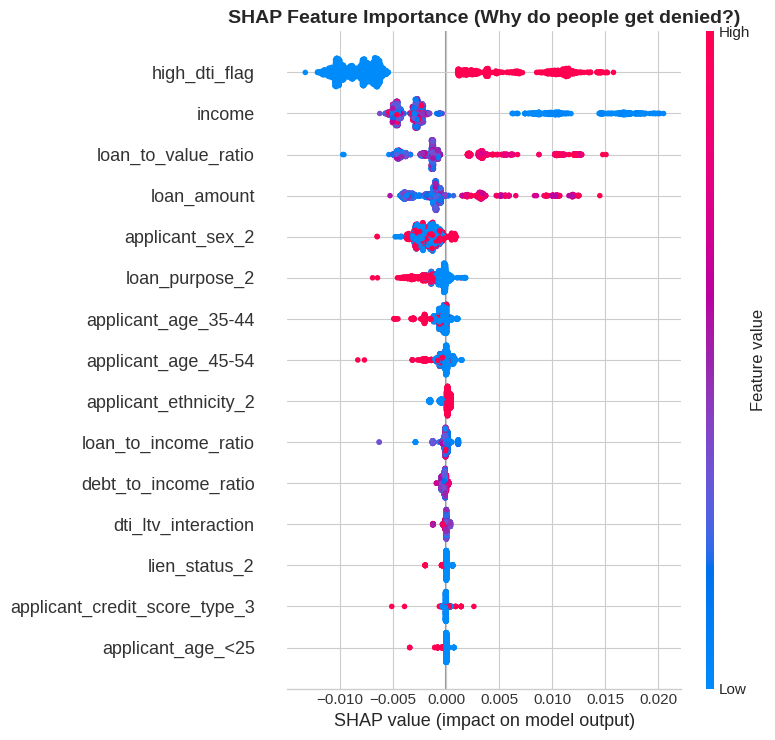

Generating SHAP Bar Plot...


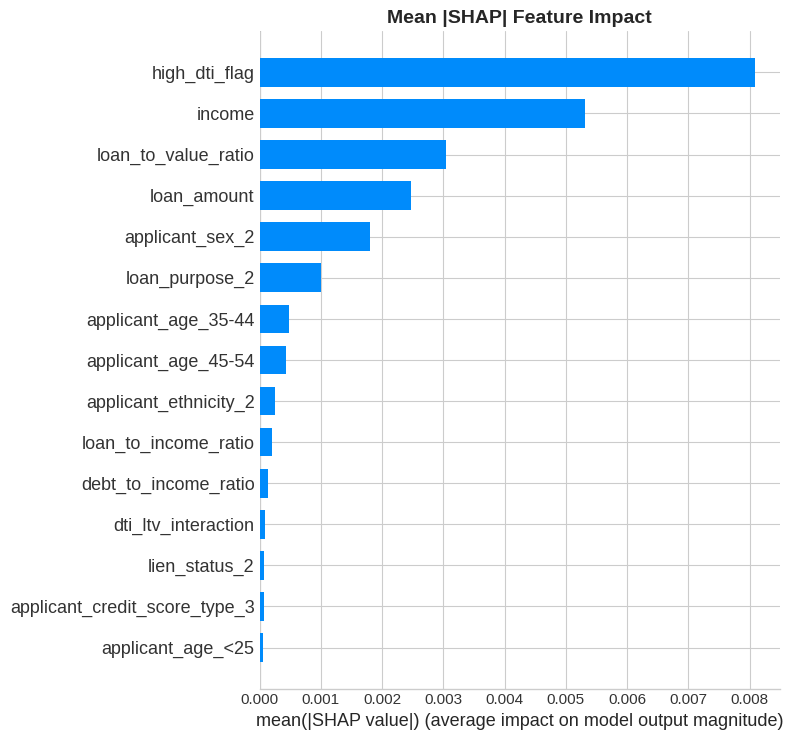

In [4]:
print("Computing SHAP values (This takes ~30 seconds)...")
explainer = shap.TreeExplainer(lgb_model)
shap_sample_size = min(2000, len(X_test))
shap_values = explainer.shap_values(X_test[:shap_sample_size])
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Get positive class (default)
print("Generating SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:shap_sample_size], feature_names=feature_names, max_display=15, show=False)
plt.title('SHAP Feature Importance (Why do people get denied?)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/fig9_shap_summary.png", bbox_inches='tight', dpi=300)
plt.show()
print("Generating SHAP Bar Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:shap_sample_size], feature_names=feature_names, plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| Feature Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/fig10_shap_bar.png", bbox_inches='tight', dpi=300)
plt.show()

# =============================================================================
# CELL 4: Fairness Audit
# =============================================================================

Running Fairness Audit (Demographics)...
Generating Fairness Dashboard...


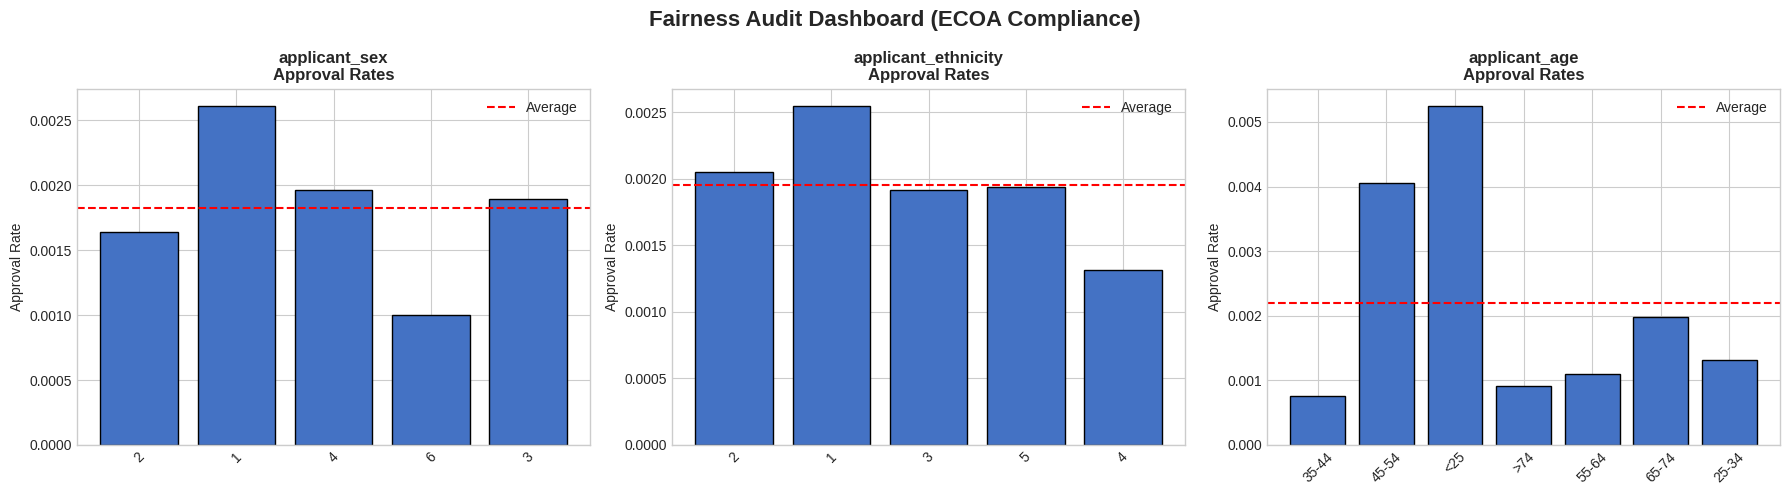


SUCCESS! Notebook 07 is fully complete. Download the 3 images from /kaggle/working!


In [5]:
print("Running Fairness Audit (Demographics)...")
y_proba = lgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
protected_attrs = ['applicant_sex', 'applicant_ethnicity', 'applicant_age']
all_fairness_results = {}
for attr in protected_attrs:
    if attr in test_df.columns:
        groups = test_df[attr].dropna().unique()
        group_metrics = []
        
        for group in groups:
            mask = test_df[attr] == group
            if mask.sum() < 30: continue
                
            pred_g = y_pred[mask]
            approval_rate = 1 - pred_g.mean()  # 1 = denied, 0 = approved
            group_metrics.append({'group': str(group), 'approval_rate': approval_rate})
            
        all_fairness_results[attr] = group_metrics
print("Generating Fairness Dashboard...")
fig, axes = plt.subplots(1, len(all_fairness_results), figsize=(18, 5))
if len(all_fairness_results) == 1: axes = [axes]
for idx, (attr_name, metrics) in enumerate(all_fairness_results.items()):
    groups = [g['group'][:15] for g in metrics] 
    approval_rates = [g['approval_rate'] for g in metrics]
    
    axes[idx].bar(groups, approval_rates, color='#4472C4', edgecolor='black')
    axes[idx].set_title(f'{attr_name}\nApproval Rates', fontweight='bold')
    axes[idx].set_ylabel('Approval Rate')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].axhline(np.mean(approval_rates), color='red', ls='--', label='Average')
    axes[idx].legend()
plt.suptitle('Fairness Audit Dashboard (ECOA Compliance)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/fig11_fairness_dashboard.png", bbox_inches='tight', dpi=300)
plt.show()
print("\nSUCCESS! Notebook 07 is fully complete. Download the 3 images from /kaggle/working!")